# \(B^\pm\to K^\pm K^\pm K^\mp\) — simultaneous direct-CP amplitude fit

This notebook targets the current **`main`** public API of `DalitzPlotFitter`.

Final convention:

- fit variables are fully **unfolded**; the two identical \(K^+\) are
  particles \((0,1)\) in `('K+', 'K+', 'K-')`, so `Resonance` amplitudes are
  automatically symmetrized and the unbinned fit is already correct without
  any folding of the fit sample itself;
- ROOT `s31` is mapped to internal `s13`;
- invariants are in GeV²;
- all resonances use pair `(0,2)`;
- `normalize_components=True`;
- normalization uses `toy-mc`: one flat 1,000,000-event `PhaseSpaceMC`
  sample, generated once and shared unchanged between the B+ and B- models
  (`normalization_sample=`), so integration noise does not differ between
  charges;
- the Laura++ `LauRescattering2Res` port (`Rescattering2`) is included as a coherent spin-0 K+K- amplitude;
- a D0 -> K+K- veto removes +/-60 MeV around the D0 mass, and a J/psi ->
  K+K- veto removes +/-30 MeV around the J/psi mass, both in each opposite-sign
  K+K- pairing (`s13` and `s23`) and both charges; both half-widths are
  configurable (`D0_VETO_HALF_WIDTH_GEV`, `JPSI_VETO_HALF_WIDTH_GEV`). The
  model does not fit an explicit `Jpsi_1S` component — that region is
  excised by the veto instead;
- only the BaBar Table-I baseline amplitudes are fit, with the ad hoc
  `X0(1550)` pole replaced by the established `f0(1500)` and `f2'(1525)`
  resonances: `phi1020`, `f0_980`, `rescattering2`, `f0_1500`, `f2p_1525`,
  `f0_1710`, `phi1680`, `chic0`, `NR` — the previous additional test
  amplitudes (`f2_1270`, `chic2`) have been removed;
- background and efficiency are built directly from the ROOT files' own
  `mPrime`/`thPrime` branches, which are already folded onto
  \(\theta'\in[0,0.5]\) for the identical-\(K^+\) pair `SQDP_PAIR=(0,1)`
  (verified numerically against the reconstructed candidate mass) —
  `SquareDalitzHistogramBackground`/`SquareDalitzHistogramEfficiency` are
  built directly on that half-domain with `folded=True`, no manual
  mirroring needed. The same pair is used for postfit Square-Dalitz
  visualization, and postfit data panels plot the real `mPrime`/`thPrime`
  branches directly (masked by the same D0/J-psi veto as the fit data)
  rather than recomputing them;
- postfit plots include `s13`, `s23`, `m13`, `m23`,
  1D SqDP projections (`mPrime`, `thetaPrime`), full 2D SqDP, and the
  unfolded Dalitz plane; prefit plots are skipped in this run;
- Minuit defaults: verbosity 3, strategy 1;
- the fit is **extended** (`CPFitSession(extended=True, signal_yield=...)`):
  the total signal yield `N_signal` and the raw signal yield asymmetry
  `A_yield` between B+ and B- are independent fit parameters via
  `YieldAsymmetry`, and the combinatorial background gets its own
  independent yield `N_combinatorial` (`with_background(..., yield_=...)`)
  instead of a shared `signal_fraction`. `A_yield` is a raw counting CP
  asymmetry, distinct from `CPRealImag`'s coefficient-level `A_CP` reported
  below (see `docs/cp_coefficients.md`, "Yield-asymmetry parameterization").

Efficiency is built separately for B+ and B- from
`mclarge151617_kkk.root`, after applying the same data mass window, directly
from its `mPrime`/`thPrime` branches, histogrammed with
`weights=Event_PIDCalibEff` (sum of weights per bin) and smoothed.

Events with non-positive `Event_PIDCalibEff` are reported for diagnostics and excluded from the efficiency-map sample. The map itself is still filled with `weights=Event_PIDCalibEff`, i.e. the sum of weights in each bin.

Before filling the efficiency map, MC events with non-finite `mPrime`/`thPrime`, coordinates outside the folded SqDP domain, non-finite `Event_PIDCalibEff`, or `Event_PIDCalibEff <= 0` are reported and removed.

Implementation note: the notebook delegates fitting to `CPFitSession.fit`
(or `fit_multistart`) and delegates folded Square-Dalitz histogram
evaluation to `SquareDalitzHistogramBackground`/
`SquareDalitzHistogramEfficiency`. Custom code is retained only to build the
already-folded `(mPrime, thPrime)` histograms from ROOT, smooth them, and
render the postfit diagnostics not exposed by the public session API.


In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"


# Já é o padrão; útil se essa opção estava desabilitada.
flags = os.environ.get("XLA_FLAGS", "")
os.environ["XLA_FLAGS"] = (
    flags + " --xla_cpu_multi_thread_eigen=true"
).strip()

os.environ["JAX_PLATFORMS"] = "cuda" # cpu, gpu, tpu

In [2]:

from dataclasses import dataclass, replace
from pathlib import Path
import inspect

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dalitzplotfitter import (
    BaBarFlatte,
    CompositeVeto,
    CPFitSession,
    CPRealImag,
    DalitzAmplitude,
    MassWindowVeto,
    DecayChannel,
    DecayModel,
    Parameter,
    PhaseSpaceMC,
    Resonance,
    Rescattering2,
    SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency,
    YieldAsymmetry,
    GounarisSakurai,
    enable_x64,
    plot_pulls,
    read_phase_space_sample,
    read_root_tree,
)

enable_x64()

# Fail early if an older checkout is accidentally used.
_fit_signature = inspect.signature(CPFitSession.fit)
if 'strategy' not in _fit_signature.parameters or 'hesse' not in _fit_signature.parameters:
    raise RuntimeError(
        "This notebook requires the current DalitzPlotFitter main branch: "
        "CPFitSession.fit must expose strategy= and hesse=."
    )


## Configuration

In [3]:
ROOT_FILE = Path('/home/juan-leite/Work/data/B2KKK_data.root')
TREE_NAME = 'DecayTree'

MC_FILE = Path('/home/juan-leite/Work/data/mclarge151617_kkk.root')
MC_TREE_NAME = 'DecayTree'

BRANCH = {
    'mass': 'B_m',
    'charge': 'B_charge',
    's12': 's12',
    's13': 's31',
    's23': 's23',
    # Already-folded Square-Dalitz coordinates (thPrime in [0, 0.5]).
    'mprime': 'mPrime',
    'thetaprime': 'thPrime',
}

MC_BRANCH = {
    'mass': 'B_m',
    'charge': 'B_charge',
    'mprime': 'mPrime',
    'thetaprime': 'thPrime',
    'pid_eff': 'Event_PIDCalibEff',
}

INVARIANT_UNIT = 'GeV2'

BPLUS_CHARGE_VALUE = +1
BMINUS_CHARGE_VALUE = -1

SIGNAL_MASS_WINDOW = (5230.0, 5330.0)
BKG_MASS_MIN = 5500.0

D0_MASS_GEV = 1.86484
D0_VETO_HALF_WIDTH_GEV = 0.060

# J/psi(1S) -> K+K- veto, same window convention as the D0 veto above
# (configurable half-width, applied to both opposite-sign K+K- pairings and
# both charges); the model itself no longer fits a Jpsi_1S component.
JPSI_MASS_GEV = 3.096900
JPSI_VETO_HALF_WIDTH_GEV = 0.030

M_B_GEV = 5.27934
M_K_GEV = 0.493677
DAUGHTER_MASSES = (M_K_GEV, M_K_GEV, M_K_GEV)

# The two identical K+ are particles (0, 1) in ('K+', 'K+', 'K-'); this is
# the pair that must be used for the Square-Dalitz (m', theta') convention
# for `folded=True` to be valid (exchanging it leaves m' fixed and maps
# theta' -> 1 - theta'), and it matches the pair used to compute the ROOT
# files' own mPrime/thPrime branches (verified numerically against B_m).
# Used both for the goodness_of_fit_chi2(square_dalitz=True) postfit checks
# and for the folded background/efficiency Square-Dalitz histograms below.
SQDP_PAIR = (0, 1)

# toy-mc normalization: one shared flat phase-space sample (same masses for
# both charges) reused for both plus_model and minus_model, so integration
# noise does not differ between B+ and B- and bias the charge asymmetry.
NORMALIZATION_MC_SIZE = 1_000_000
NORMALIZATION_MC_SEED = 20260910

# (mPrime bins, thetaPrime-half bins): mPrime spans [0, 1], thetaPrime spans
# [0, 0.5] since the histograms are built directly from the already-folded
# ROOT mPrime/thPrime branches and evaluated with folded=True.
SEPARATE_BKG_BY_CHARGE = False
BACKGROUND_BINS = (45, 45)
BACKGROUND_SMOOTH_SIGMA = 1.0

USE_EFFICIENCY = True
EFFICIENCY_BINS = (45, 45)
EFFICIENCY_SMOOTH_SIGMA = 1.0

# Extended fit: N_signal, A_yield and N_combinatorial are known from an
# external measurement (e.g. an extended ML fit to the B mass spectrum) and
# are fixed (not floated) in this Dalitz fit -- only the amplitude
# parameters are free. YieldAsymmetry's raw counting asymmetry
# A_yield = (N_minus - N_plus) / N_s is independent of CPRealImag's
# coefficient-level A_CP (see docs/cp_coefficients.md).
SIGNAL_YIELD = 323_514  # TODO: set to the known N_signal
YIELD_ASYMMETRY = -0.037  # TODO: set to the known A_yield
BACKGROUND_YIELD =  11_826 + 30 # TODO: set to the known N_combinatorial

FIT_NSTARTS = 1
FIT_SEED = 20260903
FIT_TOLERANCE = 1e-4
FIT_VERBOSE = 3
FIT_STRATEGY = 1

PROJECTION_SIZE = 1_000_000
PROJECTION_BINS = 100

## Load unfolded signal data and folded sideband SqDP

In [4]:
def signal_cut(charge=None):
    lo, hi = SIGNAL_MASS_WINDOW
    cut = f"({BRANCH['mass']} >= {lo}) & ({BRANCH['mass']} <= {hi})"
    if charge is not None:
        cut += f" & ({BRANCH['charge']} == {charge})"
    return cut


def sideband_cut(charge=None):
    cut = f"({BRANCH['mass']} > {BKG_MASS_MIN})"
    if charge is not None:
        cut += f" & ({BRANCH['charge']} == {charge})"
    return cut


def convert_to_gev2(sample):
    if INVARIANT_UNIT == 'GeV2':
        return sample
    if INVARIANT_UNIT != 'MeV2':
        raise ValueError("INVARIANT_UNIT must be 'GeV2' or 'MeV2'")

    scale = 1e-6
    return PhaseSpaceSample(
        s12=jnp.asarray(sample.s12) * scale,
        s13=jnp.asarray(sample.s13) * scale,
        s23=jnp.asarray(sample.s23) * scale,
        weights=jnp.asarray(sample.weights),
        p1=sample.p1,
        p2=sample.p2,
        p3=sample.p3,
    )


def load_signal_sample(charge):
    sample = read_phase_space_sample(
        ROOT_FILE,
        TREE_NAME,
        s12=BRANCH['s12'],
        s13=BRANCH['s13'],
        s23=BRANCH['s23'],
        cut=signal_cut(charge),
    )
    return convert_to_gev2(sample)


def load_sideband_sqdp(charge):
    """Sideband events' already-folded (mPrime, thPrime), read directly."""
    return read_root_tree(
        ROOT_FILE,
        TREE_NAME,
        {
            'mprime': BRANCH['mprime'],
            'thetaprime': BRANCH['thetaprime'],
        },
        cut=sideband_cut(charge),
    )


def _mass_veto(mass_gev, half_width_gev):
    """CompositeVeto removing |m(KK) - mass_gev| <= half_width_gev in both
    opposite-sign K+K- pairings ((0,2) and (1,2))."""
    return CompositeVeto(
        MassWindowVeto((0, 2), mass_gev - half_width_gev, mass_gev + half_width_gev),
        MassWindowVeto((1, 2), mass_gev - half_width_gev, mass_gev + half_width_gev),
    )


D0_VETO = _mass_veto(D0_MASS_GEV, D0_VETO_HALF_WIDTH_GEV)
JPSI_VETO = _mass_veto(JPSI_MASS_GEV, JPSI_VETO_HALF_WIDTH_GEV)
CHARM_VETO = CompositeVeto(D0_VETO, JPSI_VETO)

_samples_before_veto = {
    'plus': load_signal_sample(BPLUS_CHARGE_VALUE),
    'minus': load_signal_sample(BMINUS_CHARGE_VALUE),
}
_samples_after_d0 = {
    charge: D0_VETO.apply(sample)
    for charge, sample in _samples_before_veto.items()
}
samples = {
    charge: JPSI_VETO.apply(sample)
    for charge, sample in _samples_after_d0.items()
}

for charge in ('plus', 'minus'):
    before = _samples_before_veto[charge].size
    after_d0 = _samples_after_d0[charge].size
    after_jpsi = samples[charge].size
    print(
        f"D0->KK veto   {charge:5s}: removed {before-after_d0:,} / {before:,} "
        f"events in |m(KK)-m(D0)| <= {1000.0*D0_VETO_HALF_WIDTH_GEV:.0f} MeV"
    )
    print(
        f"J/psi->KK veto {charge:5s}: removed {after_d0-after_jpsi:,} / {after_d0:,} "
        f"events in |m(KK)-m(J/psi)| <= {1000.0*JPSI_VETO_HALF_WIDTH_GEV:.0f} MeV"
    )


def load_signal_sqdp(charge_value, charge_key):
    """Signal-window (mPrime, thPrime), masked to match samples[charge_key]
    exactly: same signal_cut, then the same CHARM_VETO acceptance computed
    from the s13/s23 branches read alongside."""
    raw = read_root_tree(
        ROOT_FILE,
        TREE_NAME,
        {
            's13': BRANCH['s13'],
            's23': BRANCH['s23'],
            'mprime': BRANCH['mprime'],
            'thetaprime': BRANCH['thetaprime'],
        },
        cut=signal_cut(charge_value),
    )
    mask = np.asarray(
        CHARM_VETO.accept({'s13': jnp.asarray(raw['s13']), 's23': jnp.asarray(raw['s23'])})
    )
    coords = {
        'mprime': np.asarray(raw['mprime'])[mask],
        'thetaprime': np.asarray(raw['thetaprime'])[mask],
    }
    if coords['mprime'].size != samples[charge_key].size:
        raise RuntimeError(
            f"{charge_key}: signal_sqdp size {coords['mprime'].size} != "
            f"samples size {samples[charge_key].size}"
        )
    return coords


signal_sqdp = {
    'plus': load_signal_sqdp(BPLUS_CHARGE_VALUE, 'plus'),
    'minus': load_signal_sqdp(BMINUS_CHARGE_VALUE, 'minus'),
}

bkg_sqdp = {
    'plus': load_sideband_sqdp(BPLUS_CHARGE_VALUE),
    'minus': load_sideband_sqdp(BMINUS_CHARGE_VALUE),
    'all': load_sideband_sqdp(None),
}

raw_control = read_root_tree(
    ROOT_FILE,
    TREE_NAME,
    {'mass': BRANCH['mass'], 'charge': BRANCH['charge']},
)
raw_control = {name: np.asarray(values) for name, values in raw_control.items()}

print(f"B+ signal events: {samples['plus'].size:,}")
print(f"B- signal events: {samples['minus'].size:,}")
print(f"ROOT candidates:  {len(raw_control['mass']):,}")
def mc_signal_cut(charge):
    """Use exactly the data signal-mass window and one B charge."""
    lo, hi = SIGNAL_MASS_WINDOW
    return (
        f"({MC_BRANCH['mass']} >= {lo}) & "
        f"({MC_BRANCH['mass']} <= {hi}) & "
        f"({MC_BRANCH['charge']} == {charge})"
    )


def load_efficiency_mc(charge):
    """Load the already-folded (mPrime, thPrime) and PID weight from MC."""
    return read_root_tree(
        MC_FILE,
        MC_TREE_NAME,
        {
            'mprime': MC_BRANCH['mprime'],
            'thetaprime': MC_BRANCH['thetaprime'],
            'pid_eff': MC_BRANCH['pid_eff'],
        },
        cut=mc_signal_cut(charge),
    )


def sanitize_efficiency_mc(coords, charge_label):
    """Remove entries that cannot contribute to a physical efficiency map."""
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    pid_eff = np.asarray(coords['pid_eff'], dtype=float)

    finite_mp = np.isfinite(mp)
    finite_tp = np.isfinite(tp)
    finite_pid = np.isfinite(pid_eff)

    valid = (
        finite_mp
        & finite_tp
        & finite_pid
        & (mp >= 0.0)
        & (mp <= 1.0)
        & (tp >= 0.0)
        & (tp <= 0.5)
        & (pid_eff > 0.0)
    )

    n_total = int(mp.size)
    n_valid = int(np.count_nonzero(valid))
    n_removed = n_total - n_valid

    print(f"\nEfficiency MC sanitation: {charge_label}")
    print(f"  total in mass/charge selection : {n_total:,}")
    print(f"  valid for efficiency map       : {n_valid:,}")
    print(
        f"  removed                        : {n_removed:,} "
        f"({100.0*n_removed/max(n_total,1):.5f}%)"
    )
    print(f"    non-finite mPrime             : {np.count_nonzero(~finite_mp):,}")
    print(f"    non-finite thPrime            : {np.count_nonzero(~finite_tp):,}")
    print(f"    non-finite Event_PIDCalibEff  : {np.count_nonzero(~finite_pid):,}")
    print(
        "    finite PID efficiency <= 0    : "
        f"{np.count_nonzero(finite_pid & (pid_eff <= 0.0)):,}"
    )

    if n_valid == 0:
        raise RuntimeError(f"{charge_label}: no valid efficiency-MC events")

    return {
        'mprime': jnp.asarray(mp[valid]),
        'thetaprime': jnp.asarray(tp[valid]),
        'pid_eff': jnp.asarray(pid_eff[valid]),
    }


efficiency_mc_raw = {
    'plus': load_efficiency_mc(BPLUS_CHARGE_VALUE),
    'minus': load_efficiency_mc(BMINUS_CHARGE_VALUE),
}

efficiency_mc = {
    'plus': sanitize_efficiency_mc(efficiency_mc_raw['plus'], 'B+'),
    'minus': sanitize_efficiency_mc(efficiency_mc_raw['minus'], 'B-'),
}

print(f"\nEfficiency MC retained B+: {len(efficiency_mc['plus']['mprime']):,}")
print(f"Efficiency MC retained B-: {len(efficiency_mc['minus']['mprime']):,}")

D0->KK veto   plus : removed 3,894 / 190,341 events in |m(KK)-m(D0)| <= 60 MeV
J/psi->KK veto plus : removed 7,259 / 186,447 events in |m(KK)-m(J/psi)| <= 30 MeV
D0->KK veto   minus: removed 3,763 / 172,511 events in |m(KK)-m(D0)| <= 60 MeV
J/psi->KK veto minus: removed 6,150 / 168,748 events in |m(KK)-m(J/psi)| <= 30 MeV
B+ signal events: 179,188
B- signal events: 162,598
ROOT candidates:  529,235

Efficiency MC sanitation: B+
  total in mass/charge selection : 1,287,105
  valid for efficiency map       : 1,286,803
  removed                        : 302 (0.02346%)
    non-finite mPrime             : 0
    non-finite thPrime            : 0
    non-finite Event_PIDCalibEff  : 0
    finite PID efficiency <= 0    : 302

Efficiency MC sanitation: B-
  total in mass/charge selection : 1,275,743
  valid for efficiency map       : 1,275,433
  removed                        : 310 (0.02430%)
    non-finite mPrime             : 0
    non-finite thPrime            : 1
    non-finite Event_PIDCali

In [5]:

def validate_inputs():
    for charge, sample in samples.items():
        for variable in ('s12', 's13', 's23'):
            values = np.asarray(getattr(sample, variable), dtype=float)
            if np.any(~np.isfinite(values)):
                raise RuntimeError(f"{charge}: non-finite {variable}")

        s13 = np.asarray(sample.s13, dtype=float)
        s23 = np.asarray(sample.s23, dtype=float)
        print(
            f"{charge:5s}: "
            f"s13=[{s13.min():.4f},{s13.max():.4f}] GeV^2, "
            f"s23=[{s23.min():.4f},{s23.max():.4f}] GeV^2, "
            f"fraction(s13>s23)={np.mean(s13 > s23):.3f}"
        )

    for charge, coords in signal_sqdp.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)

        if coords['mprime'].size != samples[charge].size:
            raise RuntimeError(f"{charge}: signal_sqdp size mismatch with samples")
        if np.any(~np.isfinite(mp)) or np.any(~np.isfinite(tp)):
            raise RuntimeError(f"{charge}: non-finite mPrime/thPrime")
        if np.any((mp < 0.0) | (mp > 1.0)):
            raise RuntimeError(f"{charge}: mPrime outside [0,1]")
        if np.any((tp < 0.0) | (tp > 0.5)):
            raise RuntimeError(f"{charge}: thPrime outside [0,0.5]")

        print(
            f"{charge:5s}: "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}]"
        )

    for charge, coords in bkg_sqdp.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)

        if np.any(~np.isfinite(mp)) or np.any(~np.isfinite(tp)):
            raise RuntimeError(f"BKG {charge}: non-finite SqDP coordinates")
        if np.any((mp < 0.0) | (mp > 1.0)):
            raise RuntimeError(f"BKG {charge}: mPrime outside [0,1]")
        if np.any((tp < 0.0) | (tp > 0.5)):
            raise RuntimeError(f"BKG {charge}: thPrime outside [0,0.5]")

        print(
            f"BKG {charge:5s}: "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}]"
        )

    # Efficiency samples have already been sanitized; these are internal checks.
    for charge, coords in efficiency_mc.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)
        pid_eff = np.asarray(coords['pid_eff'], dtype=float)

        assert np.all(np.isfinite(mp))
        assert np.all(np.isfinite(tp))
        assert np.all(np.isfinite(pid_eff))
        assert np.all((0.0 <= mp) & (mp <= 1.0))
        assert np.all((0.0 <= tp) & (tp <= 0.5))
        assert np.all(pid_eff > 0.0)

        print(
            f"EFF {charge:5s}: N={len(mp):,}, "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}], "
            f"Event_PIDCalibEff=[{pid_eff.min():.6g},{pid_eff.max():.6g}]"
        )


validate_inputs()


plus : s13=[0.9749,23.3031] GeV^2, s23=[0.9749,23.3414] GeV^2, fraction(s13>s23)=0.500
minus: s13=[0.9750,23.3030] GeV^2, s23=[0.9750,23.2199] GeV^2, fraction(s13>s23)=0.499
plus : mPrime=[0.0092,1.0000], thPrime=[0.0001,0.5000]
minus: mPrime=[0.0157,0.9993], thPrime=[0.0001,0.5000]
BKG plus : mPrime=[0.0132,0.9993], thPrime=[0.0001,0.5000]
BKG minus: mPrime=[0.0101,1.0000], thPrime=[0.0000,0.5000]
BKG all  : mPrime=[0.0101,1.0000], thPrime=[0.0000,0.5000]
EFF plus : N=1,286,803, mPrime=[0.0013,0.9999], thPrime=[0.0000,0.5000], Event_PIDCalibEff=[0.0156231,5.66502]
EFF minus: N=1,275,433, mPrime=[0.0010,1.0000], thPrime=[0.0000,0.5000], Event_PIDCalibEff=[0.0159426,47.6501]


## Folded background/efficiency histograms and display-only Square-Dalitz coordinates

In [6]:

def smooth_histogram(values, sigma):
    values = np.asarray(values, dtype=float)
    if sigma is None or sigma <= 0:
        return values

    from scipy.ndimage import gaussian_filter
    return gaussian_filter(values, sigma=float(sigma), mode='nearest')


def build_background_map(coords, bins=BACKGROUND_BINS, sigma=BACKGROUND_SMOOTH_SIGMA):
    """Already-folded (mPrime, thPrime) sideband histogram -> smoothing ->
    SquareDalitzHistogramBackground(folded=True).

    thPrime in the ROOT files is already folded onto [0, 0.5] for the
    identical-K+ pair SQDP_PAIR, so the histogram is built directly on that
    half-domain; folded=True folds any query point onto it again at
    evaluation time (evaluated from the fit's own s12/s13/s23 via
    invariants_to_square_dalitz), so no explicit mirroring is needed.
    """
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    nx, ny = bins

    hist, mp_edges, tp_edges = np.histogram2d(
        mp, tp, bins=(nx, ny), range=((0.0, 1.0), (0.0, 0.5)),
    )

    hist = smooth_histogram(hist, sigma)
    hist = np.maximum(hist, 0.0)

    if not np.any(hist > 0.0):
        raise RuntimeError("Empty sideband histogram")

    model = SquareDalitzHistogramBackground(
        mprime_edges=mp_edges,
        thetaprime_edges=tp_edges,
        values=jnp.asarray(hist),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
        folded=True,
    )

    return model, (hist, mp_edges, tp_edges)


def build_efficiency_map(coords, bins=EFFICIENCY_BINS, sigma=EFFICIENCY_SMOOTH_SIGMA):
    """PID-weighted already-folded (mPrime, thPrime) MC -> smoothing ->
    SquareDalitzHistogramEfficiency(folded=True).

    The histogram is the SUM of Event_PIDCalibEff weights per bin. No
    mean-by-bin and no independent per-charge rescaling are applied.
    """
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    pid_eff = np.asarray(coords['pid_eff'], dtype=float)
    nx, ny = bins

    weighted, mp_edges, tp_edges = np.histogram2d(
        mp, tp, bins=(nx, ny), range=((0.0, 1.0), (0.0, 0.5)), weights=pid_eff,
    )
    weighted = np.maximum(weighted, 0.0)

    if not np.any(weighted > 0.0):
        raise RuntimeError("Empty PID-weighted efficiency histogram")

    smoothed = smooth_histogram(weighted, sigma)
    smoothed = np.maximum(smoothed, 0.0)

    model = SquareDalitzHistogramEfficiency(
        mprime_edges=mp_edges,
        thetaprime_edges=tp_edges,
        values=jnp.asarray(smoothed),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
        folded=True,
    )

    return model, (smoothed, mp_edges, tp_edges)


## BABAR Table-I model

In [7]:
COEFFICIENT_STARTS = {
    # BaBar baseline starting values, plus rho0(770)/rho0(1450)/rho0(1700)
    # added beyond the BaBar Table-I model (start=small like the other
    # subdominant components below, since there is no baseline value to
    # inherit for them).
    'phi1020': dict(rho=1.66, phase=2.99),
    'rho0_770': dict(rho=0.10, phase=0.00),
    'rho0_1450': dict(rho=0.10, phase=0.00),
    'rho0_1700': dict(rho=0.10, phase=0.00),
    'f0_980': dict(rho=5.20, phase=0.48),
    'rescattering2': dict(rho=0.10, phase=0.00),
    'f0_1500': dict(rho=8.20, phase=1.29),
    'f2p_1525': dict(rho=0.10, phase=0.00),
    'f0_1710': dict(rho=1.22, phase=-0.59),
    'phi1680': dict(rho=0.10, phase=0.00),
    'chic0': dict(rho=0.437, phase=-1.02),
    'NR': dict(rho=13.2, phase=0.00),
}


def polar_to_xy(rho, phase):
    return float(rho * np.cos(phase)), float(rho * np.sin(phase))


def make_cp_coefficients():
    result = {}

    for name, config in COEFFICIENT_STARTS.items():
        x0, y0 = polar_to_xy(config['rho'], config['phase'])
        is_reference = name == 'phi1020'

        # phi1020 is the global reference: x, y fixed to remove the overall
        # amplitude scale/phase, dy fixed, only dx free (below). Every other
        # component -- including chic0, which no longer gets a charmonium-
        # specific dx=dy=0 constraint -- is a fully free CPRealImag.
        x = Parameter.coefficient(
            f'{name}.x',
            x0,
            owner=name,
            fixed=is_reference,
            step=0.01,
        )
        y = Parameter.coefficient(
            f'{name}.y',
            y0,
            owner=name,
            fixed=is_reference,
            step=0.01,
        )

        # Reference (phi1020) convention: dx free, dy fixed.
        dx = Parameter.coefficient(
            f'{name}.dx',
            0.0,
            owner=name,
            fixed=False,
            step=0.005,
        )
        dy = Parameter.coefficient(
            f'{name}.dy',
            0.0,
            owner=name,
            fixed=is_reference,
            step=0.005,
        )

        result[name] = CPRealImag(x, y, dx, dy)

    return result


@dataclass(frozen=True)
class BaBarExponentialNR:
    alpha: object

    def __call__(self, data):
        alpha = jnp.asarray(self.alpha)
        return (
            jnp.exp(-alpha * jnp.asarray(data['s13']))
            + jnp.exp(-alpha * jnp.asarray(data['s23']))
        ) / jnp.sqrt(2.0)


def build_models():
    shared = make_cp_coefficients()

    nr_alpha = Parameter.dynamics(
        'NR.alpha',
        0.152,
        owner='NR',
        bounds=(0.0, 1.0),
        step=0.002,
    )

    def components(charge):
        coefficient = {
            name: cp_coefficient.for_charge(charge)
            for name, cp_coefficient in shared.items()
        }

        return [
            Resonance(
                'phi1020',
                (0, 2),
                coefficient['phi1020'],
                mass=1.019461,
                width=0.004249,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho0_770',
                (0, 2),
                coefficient['rho0_770'],
                mass=0.775,
                width=0.149,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho0_1450',
                (0, 2),
                coefficient['rho0_1450'],
                mass=1.465,
                width=0.400,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho0_1700',
                (0, 2),
                coefficient['rho0_1700'],
                mass=1.720,
                width=0.250,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'f0_980',
                (0, 2),
                coefficient['f0_980'],
                lineshape=BaBarFlatte(),
                mass=0.965,
                width=0.0,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rescattering2',
                (0, 2),
                coefficient['rescattering2'],
                lineshape=Rescattering2(),
                # Context pole values are unused by Rescattering2 for L=0;
                # keep a physical KK value so the generic resonance wrapper
                # can build its spin-0 kinematics/barrier context.
                mass=1.47,
                width=0.0,
                spin=0,
                resonance_radius=0.0,
                parent_radius=0.0,
            ),
            Resonance(
                'f0_1500',
                (0, 2),
                coefficient['f0_1500'],
                mass=1.522,
                width=0.108,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'f2p_1525',
                (0, 2),
                coefficient['f2p_1525'],
                mass=1.5173,
                width=0.0720,
                spin=2,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'f0_1710',
                (0, 2),
                coefficient['f0_1710'],
                mass=1.715,
                width=0.125,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'phi1680',
                (0, 2),
                coefficient['phi1680'],
                mass=1.680,
                width=0.150,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'chic0',
                (0, 2),
                coefficient['chic0'],
                mass=3.41475,
                width=0.0104,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            DalitzAmplitude(
                'NR',
                dynamics=BaBarExponentialNR(nr_alpha),
                coefficient=coefficient['NR'],
            ),
        ]

    # toy-mc normalization: one flat 1M-event PhaseSpaceMC sample, generated
    # once and reused unchanged for both plus/minus DecayModel instances
    # (same mother/daughter masses for B+ and B-), auto-selecting
    # normalization_method='toy-mc'. No new integration points are drawn
    # during minimization (docs/mc_integration.md).
    #
    # PhaseSpaceMC.generate() weights carry its own proposal measure
    # (ds12 ds13 / (128*pi**3*M**2)); the deterministic grid this replaces
    # integrates in plain ds12 ds13. Rescaling by 128*pi**3*M**2 keeps the
    # same measure so the fitted density and NLL stay on the same absolute
    # scale as the previous gauss-legendre normalization (verified
    # numerically: without this factor the NLL at the BaBar starting values
    # differs by the corresponding huge constant, ~exp(11.6) per event).
    raw_normalization_mc = PhaseSpaceMC(M_B_GEV, DAUGHTER_MASSES).generate(
        NORMALIZATION_MC_SIZE,
        seed=NORMALIZATION_MC_SEED,
        include_momenta=False,
    )
    measure_factor = 128.0 * np.pi**3 * M_B_GEV**2
    normalization_mc = replace(
        raw_normalization_mc,
        weights=raw_normalization_mc.weights * measure_factor,
    )

    normalization_options = dict(
        normalization_method="gauss-legendre",
        normalization_bin_width=0.005,
        normalization_narrow_width=0.020,
        normalization_narrow_window=5.0,
        normalization_binning_factor=20.0,
        normalization_chunk_size=50_000,
    )

    plus = DecayModel(
        DecayChannel('B+', ('K+', 'K+', 'K-')),
        components(+1),
        normalize_components=True,
        **normalization_options,
        #normalization_sample=normalization_mc,
    )

    minus = DecayModel(
        DecayChannel('B-', ('K-', 'K-', 'K+')),
        components(-1),
        normalize_components=True,
        **normalization_options,
        #normalization_sample=normalization_mc,
    )

    return plus, minus, shared


plus_model, minus_model, shared_coefficients = build_models()

print("normalization_method =", plus_model.normalization_method)
print("B+ normalization points =", plus_model.normalization_sample.size)
print("B- normalization points =", minus_model.normalization_sample.size)

normalization_method = gauss-legendre
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=1.019461 GeV, Gamma=4.249 MeV; m13: m0=3.414750 GeV, Gamma=10.400 MeV; m23: m0=1.019461 GeV, Gamma=4.249 MeV; m23: m0=3.414750 GeV, Gamma=10.400 MeV); using adaptive Gauss-Legendre normalization.
B+ normalization points = 758293
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=1.019461 GeV, Gamma=4.249 MeV; m13: m0=3.414750 GeV, Gamma=10.400 MeV; m23: m0=1.019461 GeV, Gamma=4.249 MeV; m23: m0=3.414750 GeV, Gamma=10.400 MeV); using adaptive Gauss-Legendre normalization.
B- normalization points = 758293


### \(\phi(1680)\)

The model keeps the existing \(f_0(1710)\) amplitude and now also includes
\(\phi(1680)\to K^+K^-\) as a spin-1 Breit-Wigner in `pair=(0,2)`, with fixed
nominal mass and width

\[
m_{\phi(1680)}=1.680~\mathrm{GeV},\qquad
\Gamma_{\phi(1680)}=0.150~\mathrm{GeV}.
\]

Its CP-even and CP-odd coefficient parameters are free, like the other
charmless amplitudes. The initial coefficient magnitude is 0.10 with phase 0.

### CP convention for charmonium

\(\chi_{c0}\) is now a fully free `CPRealImag` component (\(x,y,dx,dy\) all float), the same as every other non-reference charmless amplitude below -- there is no longer a charmonium-specific constraint fixing its direct-CP parameters \(dx,dy\) to zero.

`phi1020` is the global CP reference: its \(x,y\) and \(dy\) are fixed, only \(dx\) floats, removing the overall amplitude scale/phase (same role `NR` used to hold). `NR` is now an ordinary free charmless amplitude.

### Rescattering and charm veto

The coherent charmless model also contains the Laura++ two-region rescattering
S-wave through `Rescattering2()`. Its complex CP coefficient is free for the
B+ and B- simultaneous fit using the same `CPRealImag` convention as the other
charmless amplitudes.

A `CompositeVeto` made from two `MassWindowVeto` objects removes

\[
|m(K^+K^-)-m_{D^0}| \le 60\,\mathrm{MeV}
\]

for both opposite-sign pairings, and a second `CompositeVeto` removes

\[
|m(K^+K^-)-m_{J/\psi}| \le 30\,\mathrm{MeV}
\]

(both half-widths configurable via `D0_VETO_HALF_WIDTH_GEV` /
`JPSI_VETO_HALF_WIDTH_GEV`). The two are combined into one `CHARM_VETO`. The
model no longer fits an explicit `Jpsi_1S` component — that mass region is
excised by the veto instead. The same combined veto is applied to the
selected data and to the fit session, so signal normalization, combinatorial
background and fit projections all use the same accepted Dalitz region.


## Simultaneous fit session

In [8]:

def build_session():
    if SEPARATE_BKG_BY_CHARGE:
        plus_background, _ = build_background_map(bkg_sqdp['plus'])
        minus_background, _ = build_background_map(bkg_sqdp['minus'])
    else:
        common_background, _ = build_background_map(bkg_sqdp['all'])
        plus_background = common_background
        minus_background = common_background

    # N_signal, A_yield and N_combinatorial are known (fixed) rather than
    # fit here -- only the amplitude parameters float.
    signal_yield = YieldAsymmetry(
        Parameter(
            'n_signal',
            SIGNAL_YIELD,
            fixed=True,
        ),
        Parameter(
            'a_cp_yield',
            YIELD_ASYMMETRY,
            fixed=True,
        ),
    )

    fit_session = CPFitSession(
        plus_model,
        minus_model,
        samples['plus'],
        samples['minus'],
        extended=True,
        signal_yield=signal_yield,
    )

    if USE_EFFICIENCY:
        plus_efficiency, _ = build_efficiency_map(efficiency_mc['plus'])
        minus_efficiency, _ = build_efficiency_map(efficiency_mc['minus'])
        fit_session = fit_session.with_efficiency(
            plus_efficiency,
            minus_efficiency,
        )

    fit_session = fit_session.with_veto(CHARM_VETO)

    fit_session = fit_session.with_background(
        'combinatorial',
        plus_background,
        minus_shape=minus_background,
        yield_=Parameter(
            'n_combinatorial',
            BACKGROUND_YIELD,
            fixed=True,
        ),
    )

    return fit_session


session = build_session()

for parameter in session.parameters:
    print(
        f"{parameter.name:24s} "
        f"value={parameter.value: .6g} fixed={parameter.fixed}"
    )


phi1020.x                value=-1.64096 fixed=True
phi1020.y                value= 0.250681 fixed=True
phi1020.dx               value= 0 fixed=False
phi1020.dy               value= 0 fixed=True
rho0_770.x               value= 0.1 fixed=False
rho0_770.y               value= 0 fixed=False
rho0_770.dx              value= 0 fixed=False
rho0_770.dy              value= 0 fixed=False
rho0_1450.x              value= 0.1 fixed=False
rho0_1450.y              value= 0 fixed=False
rho0_1450.dx             value= 0 fixed=False
rho0_1450.dy             value= 0 fixed=False
rho0_1700.x              value= 0.1 fixed=False
rho0_1700.y              value= 0 fixed=False
rho0_1700.dx             value= 0 fixed=False
rho0_1700.dy             value= 0 fixed=False
f0_980.x                 value= 4.61237 fixed=False
f0_980.y                 value= 2.40125 fixed=False
f0_980.dx                value= 0 fixed=False
f0_980.dy                value= 0 fixed=False
rescattering2.x          value= 0.1 fixed=False
resc

## Prefit and postfit helpers

In [9]:
def plot_all_diagnostics(fit_result, title_prefix, seed):
    """Folded s_low/s_high projections via `session.plot_projection`
    (data, per-component curves, total fit and pulls) -- the one postfit
    visual `CPFitSession` already implements as a single call, for both
    charges and with a shared-x-axis pull panel included.

    The quantitative 2D diagnostics (plain Dalitz, Square-Dalitz) and the
    unbinned PPD test are *not* reimplemented here a second time: they live
    in the "Goodness of fit" section below via `goodness_of_fit_chi2`/
    `plot_pulls`/`point_to_point_dissimilarity`, which is the actual
    session-level API for them. Earlier revisions of this notebook hand-rolled
    all of this (custom 1D mass-unit projections, custom Square-Dalitz 1D
    projections reading the ROOT files' own mPrime/thPrime branches, and
    custom 2D data/model/pull triptychs); those pieces are dropped rather
    than kept as one-off duplicates of what the fitter now provides directly.
    """
    for fold_side in ('low', 'high'):
        session.plot_projection(
            fit_result, 's13', partner_variable='s23',
            folded=True, fold_side=fold_side,
            bins=PROJECTION_BINS, projection_size=PROJECTION_SIZE,
            projection_seed=seed, show_pulls=True,
        )
        plt.show()


## Fit with Minuit strategy 1

In [10]:

if FIT_NSTARTS == 1:
    result = session.fit(
        simplex=False,
        strategy=FIT_STRATEGY,
        hesse=True,
        tolerance=FIT_TOLERANCE,
        verbose=FIT_VERBOSE,
    )
    scan_results = (result,)
else:
    multistart = session.fit_multistart(
        n_starts=FIT_NSTARTS,
        seed=FIT_SEED,
        include_default=True,
        simplex=False,
        strategy=FIT_STRATEGY,
        tolerance=FIT_TOLERANCE,
        verbose=FIT_VERBOSE,
    )
    result = multistart.best
    scan_results = multistart.results

fit_report = session.report(
    result,
    include_fit_fractions=False,
    include_correlation=True,
)


[Minimizer] single fit with 46 free parameters (simplex=False, strategy=1, hesse=True, ncall=None, tolerance=0.0001)
I MnSeedGenerator Using analytical (external) gradient calculator but cannot compute G2 - use then numerical gradient for G2
I MnSeedGenerator Computing seed using NumericalGradient calculator
I MnSeedGenerator Evaluated function and gradient in 9.86974 s
I MnSeedGenerator Initial state: FCN =      -2098827.181 Edm =       45490.47577 NCalls =    159
I MnSeedGenerator Initial state  
  Minimum value : -2098827.181
  Edm           : 45490.47577
  Internal parameters:	[                0              0.1                0                0                0              0.1                0                0                0              0.1....                 0]	
  Internal gradient  :	[         596.6869       223.347636     -5013.276267      1883.562359      1788.726329       3138.56285      1907.478607     -1058.484999     -314.4370836       490.564087....      -1757.344991

## Yield asymmetry

In [11]:
postfit_yield_values = session.result_values(result)

expected_total = float(session.base_objective.expected_events(postfit_yield_values))
n_signal_total = float(session.signal_yield.total.resolve(postfit_yield_values))
a_cp_yield = float(session.signal_yield.asymmetry.resolve(postfit_yield_values))
n_signal_plus = float(session.signal_yield.plus(postfit_yield_values))
n_signal_minus = float(session.signal_yield.minus(postfit_yield_values))

print(f"expected total events (signal + background): {expected_total:.2f}")
print(f"N_signal (total)  = {n_signal_total:.2f}")
print(f"A_yield           = {a_cp_yield:.4f}")
print(f"N_signal(B+)      = {n_signal_plus:.2f}")
print(f"N_signal(B-)      = {n_signal_minus:.2f}")

expected total events (signal + background): 335370.00
N_signal (total)  = 323514.00
A_yield           = -0.0370
N_signal(B+)      = 167742.01
N_signal(B-)      = 155771.99


## Fit fractions

In [12]:
fit_fractions = session.print_fit_fractions(
    result,
    acceptance_weighted=USE_EFFICIENCY,
    include_interference=False,
    precision=4,
)

plus_ff = fit_fractions['plus']
minus_ff = fit_fractions['minus']

component_names = [
    name for name in plus_ff
    if name in minus_ff
]

ff_table = pd.DataFrame({
    'component': component_names,
    'FF_plus': [float(plus_ff[name]) for name in component_names],
    'FF_minus': [float(minus_ff[name]) for name in component_names],
})

ff_table['FF_mean'] = 0.5 * (
    ff_table['FF_plus'] + ff_table['FF_minus']
)

display(ff_table)

B+ fit fractions
Fit fractions (acceptance-weighted)
component                    fraction [%]
phi1020                           12.5404
rho0_770                           0.6467
rho0_1450                          3.0373
rho0_1700                          4.1663
f0_980                            15.3336
rescattering2                      1.1133
f0_1500                           60.0488
f2p_1525                           0.6751
f0_1710                            2.7922
phi1680                            0.3241
chic0                              1.6777
NR                                42.5889
sum                              144.9444

B- fit fractions
Fit fractions (acceptance-weighted)
component                    fraction [%]
phi1020                           13.6197
rho0_770                           0.6574
rho0_1450                          9.1041
rho0_1700                          4.6054
f0_980                             8.9337
rescattering2                      3.4587
f0_1500    

,component,FF_plus,FF_minus,FF_mean
0,phi1020,0.125404,0.136197,0.130801
1,rho0_770,0.006467,0.006574,0.006520
2,rho0_1450,0.030373,0.091041,0.060707
3,rho0_1700,0.041663,0.046054,0.043858
4,f0_980,0.153336,0.089337,0.121336
5,rescattering2,0.011133,0.034587,0.022860
6,f0_1500,0.600488,0.593271,0.596879
7,f2p_1525,0.006751,0.006015,0.006383
8,f0_1710,0.027922,0.019087,0.023505
9,phi1680,0.003241,0.014203,0.008722


## CP coefficients

In [13]:
def _cp_observables(theta):
    x, y, dx, dy = theta
    c_plus = complex(x + dx, y + dy)
    c_minus = complex(x - dx, y - dy)
    mag_plus = abs(c_plus)
    mag_minus = abs(c_minus)
    phase_plus = np.angle(c_plus)
    phase_minus = np.angle(c_minus)
    denominator = mag_minus**2 + mag_plus**2
    acp = (mag_minus**2 - mag_plus**2) / denominator if denominator > 0.0 else np.nan
    delta_phase = np.angle(np.exp(1j * (phase_minus - phase_plus)))
    return np.asarray([mag_plus, mag_minus, phase_plus, phase_minus, acp, delta_phase])


def _cp_observable_errors(name, theta):
    parameter_names = [f'{name}.x', f'{name}.y', f'{name}.dx', f'{name}.dy']
    covariance = np.zeros((4, 4), dtype=float)
    fit_covariance = getattr(result, 'covariance', None)

    if fit_covariance is None:
        return np.full(6, np.nan)

    for i, par_i in enumerate(parameter_names):
        for j, par_j in enumerate(parameter_names):
            try:
                covariance[i, j] = float(fit_covariance[par_i, par_j])
            except (KeyError, TypeError):
                # Fixed parameters are absent from the Minuit covariance.
                covariance[i, j] = 0.0

    jacobian = np.empty((6, 4), dtype=float)
    angular_observables = {2, 3, 5}
    for i, value in enumerate(theta):
        step = 1.0e-6 * max(1.0, abs(value))
        theta_hi = theta.copy()
        theta_lo = theta.copy()
        theta_hi[i] += step
        theta_lo[i] -= step
        difference = _cp_observables(theta_hi) - _cp_observables(theta_lo)
        for index in angular_observables:
            difference[index] = np.angle(np.exp(1j * difference[index]))
        jacobian[:, i] = difference / (2.0 * step)

    variances = np.einsum('ai,ij,aj->a', jacobian, covariance, jacobian)
    return np.sqrt(np.maximum(variances, 0.0))


def build_cp_table():
    values = session.result_values(result)
    rows = []

    for name in COEFFICIENT_STARTS:
        x = values[f'{name}.x']
        y = values[f'{name}.y']
        dx = values[f'{name}.dx']
        dy = values[f'{name}.dy']

        theta = np.asarray([x, y, dx, dy], dtype=float)
        observables = _cp_observables(theta)
        uncertainties = _cp_observable_errors(name, theta)
        mag_plus, mag_minus, phase_plus, phase_minus, acp, delta_phase = observables
        err_mag_plus, err_mag_minus, err_phase_plus, err_phase_minus, err_acp, err_delta_phase = uncertainties

        rows.append({
            'component': name,
            '|c+|': mag_plus,
            'sigma(|c+|)': err_mag_plus,
            '|c-|': mag_minus,
            'sigma(|c-|)': err_mag_minus,
            'phi+ [rad]': phase_plus,
            'sigma(phi+) [rad]': err_phase_plus,
            'phi- [rad]': phase_minus,
            'sigma(phi-) [rad]': err_phase_minus,
            'A_CP(coeff)': acp,
            'sigma(A_CP)': err_acp,
            'delta_phi [rad]': delta_phase,
            'sigma(delta_phi) [rad]': err_delta_phase,
        })

    return pd.DataFrame(rows)


cp_table = build_cp_table()
display(cp_table)

,component,|c+|,sigma(|c+|),|c-|,sigma(|c-|),phi+ [rad],sigma(phi+) [rad],phi- [rad],sigma(phi-) [rad],A_CP(coeff),sigma(A_CP),delta_phi [rad],sigma(delta_phi) [rad]
0,phi1020,1.622206,0.137604,1.697814,0.137751,2.986440,0.013268,2.993402,0.012112,0.045524,0.165616,0.006962,0.025380
1,rho0_770,0.386709,0.040093,0.390136,0.037417,-2.429823,0.058649,-2.339901,0.065893,0.008822,0.183448,0.089922,0.085712
2,rho0_1450,0.858966,0.077556,1.485240,0.124207,0.154084,0.046789,-0.097813,0.040783,0.498721,0.125052,-0.251897,0.058122
3,rho0_1700,1.077017,0.106228,1.130227,0.131998,-2.111931,0.094946,-2.808060,0.073754,0.048187,0.187451,-0.696130,0.112998
4,f0_980,1.805217,0.161815,1.379267,0.118733,-1.139111,0.041401,-0.835469,0.053061,-0.262814,0.155278,0.303642,0.068660
5,rescattering2,0.474952,0.051229,0.838752,0.081158,2.628065,0.093593,2.984211,0.055940,0.514406,0.139902,0.356146,0.102900
6,f0_1500,3.597984,0.303960,3.571236,0.292571,-2.887153,0.028594,-2.557549,0.029761,-0.007462,0.166234,0.329603,0.039663
7,f2p_1525,0.397055,0.036028,0.374244,0.033612,1.685908,0.035049,2.159963,0.038390,-0.059099,0.172906,0.474056,0.049717
8,f0_1710,0.826113,0.072153,0.683445,0.060076,2.164251,0.032945,2.508046,0.035721,-0.187346,0.164810,0.343795,0.043854
9,phi1680,0.292327,0.077210,0.610824,0.070722,2.086149,0.165086,-2.079832,0.128609,0.627291,0.190951,2.117204,0.215813


## Postfit diagnostics

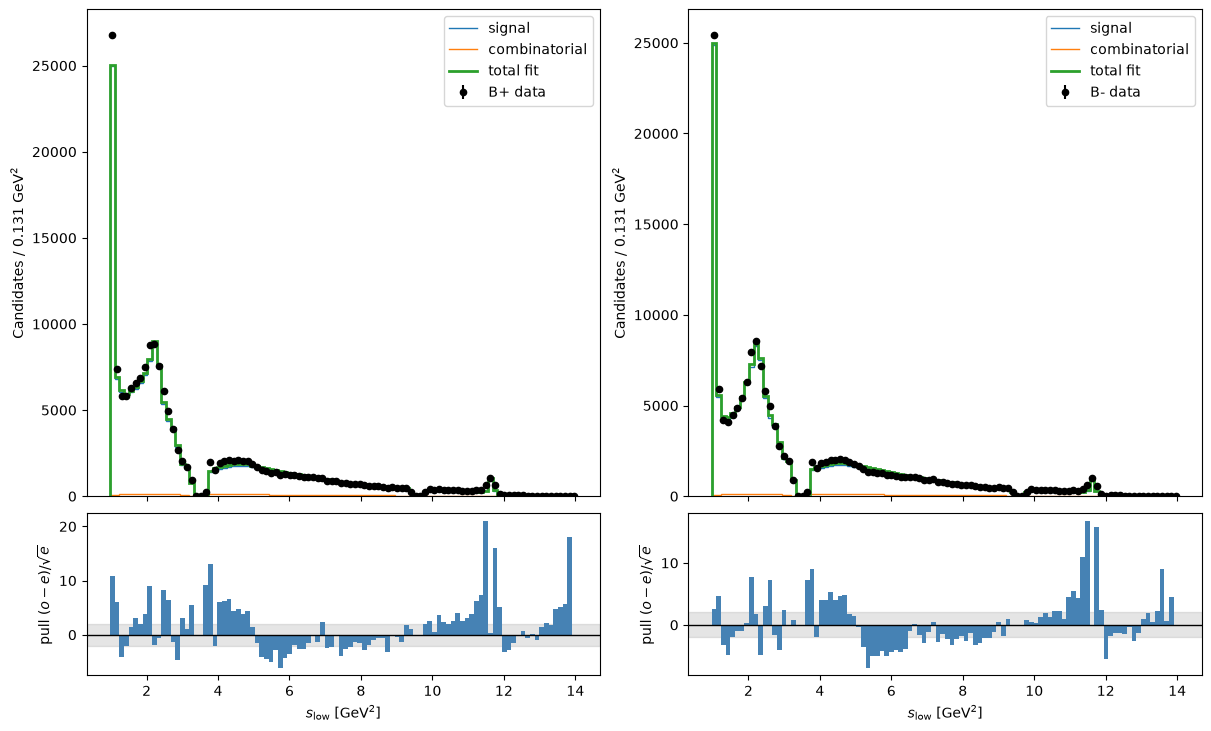

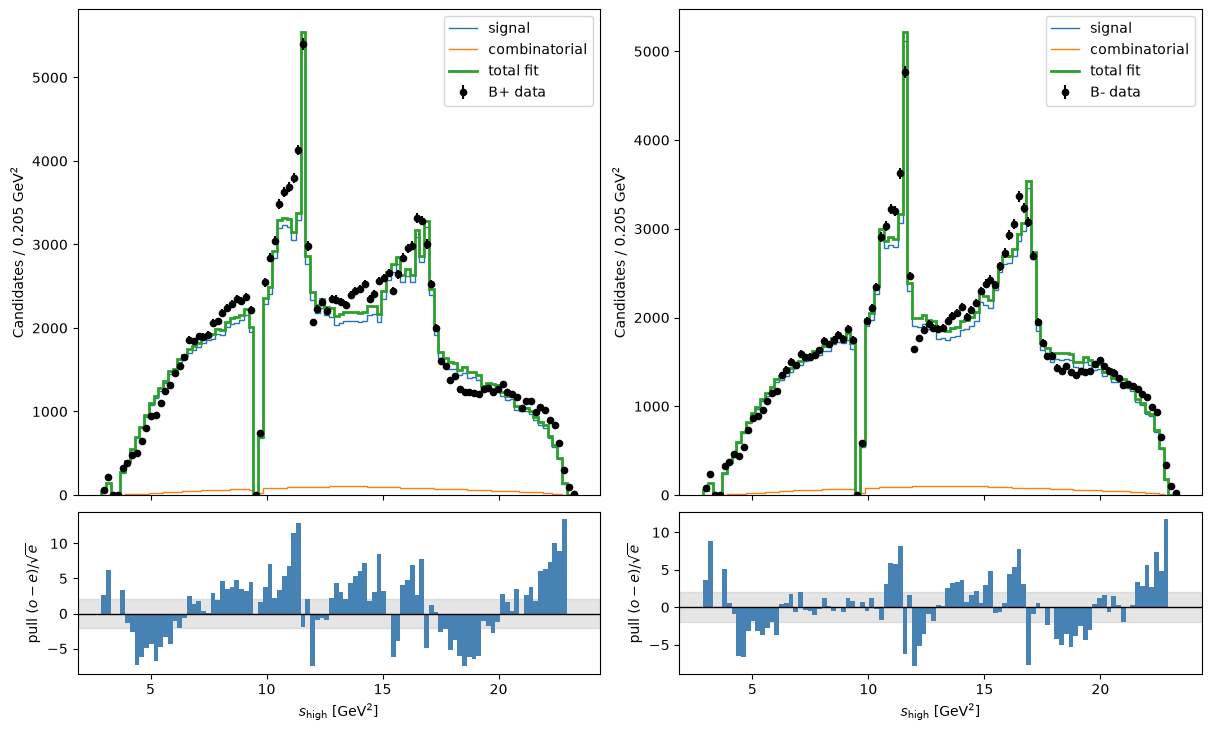

In [14]:
plot_all_diagnostics(
    result,
    title_prefix='Post-fit',
    seed=FIT_SEED + 5000,
)

## Goodness of fit

Quantitative complement to the pull panels above: the binned Pearson chi2 test
(Williams, arXiv:1006.3019, Sec. 3.1) on the folded 1D, plain Dalitz and
Square-Dalitz projections, and the unbinned point-to-point dissimilarity (PPD) test
(Williams Sec. 3.3) per charge. See `docs/goodness_of_fit.md` for the
degrees-of-freedom caveat (the amplitude parameters here come from an unbinned
fit, not from minimizing this chi2, so only a `[dof_min, dof_max]` bound on the
true p-value is available) and the `sigma_bar`/`max_total_events` tuning notes
for PPD.

PPD is `O(n^2)` in the pooled data+reference size, so it cannot run on the full
signal sample (hundreds of thousands of candidates); a dedicated reduced-data
session (`ppd_session`, same fitted models and parameters, a random subsample
of each charge's data) is built below just for that test. The chi2 tests have
no such restriction and run on the full sample, exactly like the projections
above.


Post-fit B+: 1D chi2=1437.2 (n_bins=39, dof=[-8,38], p=[nan,3.51e-277])
             Dalitz chi2=6843.1 (n_bins=546, dof=[499,545], p=[0,0])
             SqDP chi2=152503.1 (n_bins=897, dof=[850,896], p=[0,0])


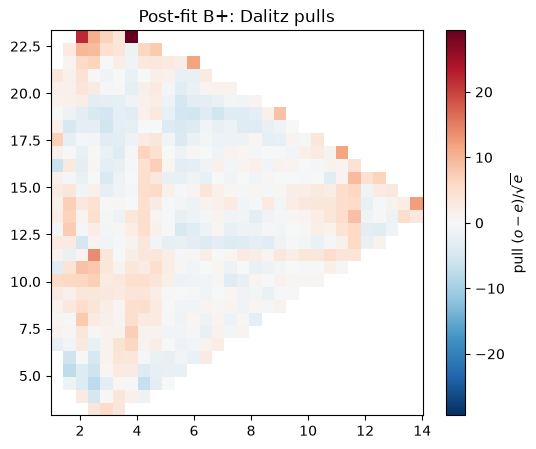

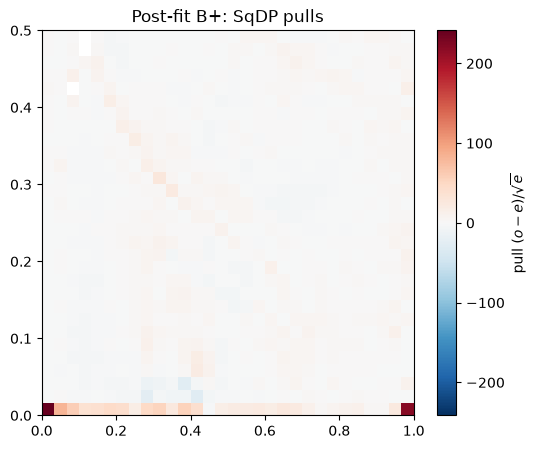

Post-fit B-: 1D chi2=943.2 (n_bins=39, dof=[-8,38], p=[nan,3.32e-173])
             Dalitz chi2=11913.5 (n_bins=549, dof=[502,548], p=[0,0])
             SqDP chi2=129649.0 (n_bins=896, dof=[849,895], p=[0,0])


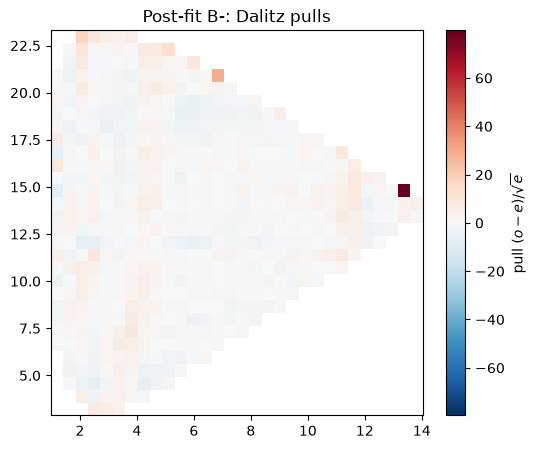

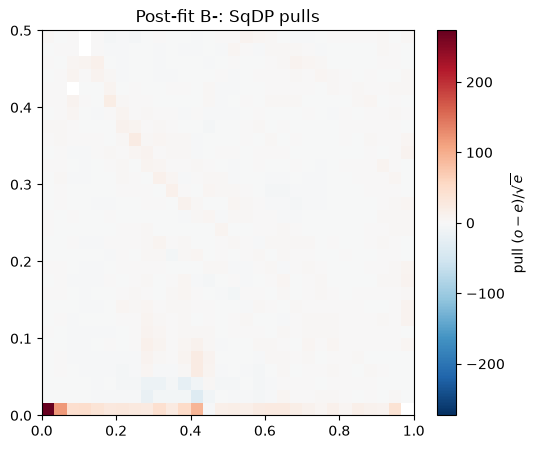

Post-fit B+: PPD statistic=5.217e-07, p=0 (n_data=2000 subsample, n_reference=3000)
Post-fit B-: PPD statistic=-2.471e-07, p=0 (n_data=2000 subsample, n_reference=3000)


In [15]:
GOF_BINS_1D = 40
GOF_BINS_2D = (30, 30)
PPD_SAMPLE_SIZE = 2000
PPD_MC_SIZE = 3000
# Derived, not duplicated: point_to_point_dissimilarity's own O(n^2) guard
# (default max_total_events=5_000) must never silently drift out of sync
# with the sizes actually requested above.
PPD_MAX_TOTAL_EVENTS = PPD_SAMPLE_SIZE + PPD_MC_SIZE
PPD_PERMUTATIONS = 200
PPD_SEED = FIT_SEED + 7000


def goodness_of_fit_summary(
    fit_result,
    title_prefix,
    bins_1d=GOF_BINS_1D,
    bins_2d=GOF_BINS_2D,
    size=PROJECTION_SIZE,
    seed=FIT_SEED,
):
    """Binned chi2 (folded s_low/s_high 1D, folded SqDP 2D) per charge.

    Bins are chosen independently from `PROJECTION_BINS` (tuned for smooth
    visual projections, not for adequate per-bin occupancy in a chi2 test);
    reduce them if any bins come out empty for the current data/model.
    """
    gof_1d = session.goodness_of_fit_projection(
        fit_result, 's13', bins=bins_1d, folded=True, partner_variable='s23',
        projection_size=size, projection_seed=seed,
    )
    gof_dalitz = session.goodness_of_fit_chi2(
        fit_result, 's13', 's23', folded=True, bins=bins_2d,
        projection_size=size, projection_seed=seed + 1,
    )
    gof_sqdp = session.goodness_of_fit_chi2(
        fit_result, square_dalitz=True, mother_mass=M_B_GEV, masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR, folded=True, bins=bins_2d,
        projection_size=size, projection_seed=seed + 2,
    )

    for charge in ('plus', 'minus'):
        label = f"{title_prefix} B{'+' if charge == 'plus' else '-'}"
        one_d = gof_1d[charge]
        dalitz = gof_dalitz[charge]
        sqdp = gof_sqdp[charge]
        print(
            f"{label}: 1D chi2={one_d.chi2:.1f} (n_bins={one_d.n_bins}, "
            f"dof=[{one_d.dof_min},{one_d.dof_max}], "
            f"p=[{one_d.p_value_min:.3g},{one_d.p_value_max:.3g}])"
        )
        print(
            f"{' ' * len(label)}  Dalitz chi2={dalitz.chi2:.1f} (n_bins={dalitz.n_bins}, "
            f"dof=[{dalitz.dof_min},{dalitz.dof_max}], "
            f"p=[{dalitz.p_value_min:.3g},{dalitz.p_value_max:.3g}])"
        )
        print(
            f"{' ' * len(label)}  SqDP chi2={sqdp.chi2:.1f} (n_bins={sqdp.n_bins}, "
            f"dof=[{sqdp.dof_min},{sqdp.dof_max}], "
            f"p=[{sqdp.p_value_min:.3g},{sqdp.p_value_max:.3g}])"
        )

        for name, two_d in (('Dalitz', dalitz), ('SqDP', sqdp)):
            fig, ax = plt.subplots(figsize=(6, 5))
            plot_pulls(two_d, ax=ax)
            ax.set_title(f'{label}: {name} pulls')
            plt.show()


def ppd_subsample(sample, size, seed):
    """A random unweighted subsample, or the sample unchanged if already small."""
    if sample.size <= size:
        return sample
    rng = np.random.default_rng(seed)
    indices = rng.choice(sample.size, size=size, replace=False)
    return sample.take(jnp.asarray(indices))


def point_to_point_summary(
    fit_result,
    title_prefix,
    sample_size=PPD_SAMPLE_SIZE,
    mc_size=PPD_MC_SIZE,
    n_permutations=PPD_PERMUTATIONS,
    seed=PPD_SEED,
    max_total_events=PPD_MAX_TOTAL_EVENTS,
):
    ppd_session = replace(
        session,
        plus_data=ppd_subsample(samples['plus'], sample_size, seed),
        minus_data=ppd_subsample(samples['minus'], sample_size, seed + 1),
    )
    for charge in ('plus', 'minus'):
        label = f"{title_prefix} B{'+' if charge == 'plus' else '-'}"
        ppd = ppd_session.point_to_point_dissimilarity(
            fit_result, charge=charge, mc_size=mc_size,
            n_permutations=n_permutations, seed=seed + 2,
            max_total_events=max_total_events,
        )
        print(
            f"{label}: PPD statistic={ppd.statistic:.3e}, p={ppd.p_value:.3g} "
            f"(n_data={ppd.n_data} subsample, n_reference={ppd.n_reference})"
        )


goodness_of_fit_summary(result, title_prefix='Post-fit')
point_to_point_summary(result, title_prefix='Post-fit')


## Folded background and efficiency

Background and efficiency are both built directly from the ROOT files' own
`mPrime`/`thPrime` branches — no invariants-to-square-Dalitz recomputation
or manual mirroring is used to build them.

The two identical \(K^+\) are particles \((0, 1)\) in `('K+', 'K+', 'K-')`;
`SQDP_PAIR = (0, 1)` is exactly this identical pair (verified numerically:
using it to recompute \(m'\)/\(\theta'\) from `s12`/`s13`/`s23` with the
per-candidate mass reproduces the stored ROOT `mPrime`/`thPrime` branches).
`thPrime` in the ROOT files is already folded onto `[0, 0.5]`, so the
histogram is built directly on that half-domain and handed to
`SquareDalitzHistogramBackground`/`SquareDalitzHistogramEfficiency` with
`folded=True`, `pair=SQDP_PAIR` — evaluation (on the fit's own `s12`/`s13`/
`s23`) recomputes \(m'\)/\(\theta'\) internally and folds any query point
onto the same half, so no explicit unfolding/mirroring step is required.

The "Goodness of fit" section's `goodness_of_fit_chi2(square_dalitz=True)`
calls, unlike this background/efficiency construction, always recompute
\(m'\)/\(\theta'\) from `s12`/`s13`/`s23` for *both* data and model --
`CPFitSession` has no hook to substitute the ROOT files' own `mPrime`/
`thPrime` branches for the data side there. The two are numerically close
(see the `SQDP_PAIR` verification note above) but not identical; this is a
deliberate simplification to keep the postfit checks expressed entirely in
terms of the fitter's own public API rather than a second, hand-rolled
recomputation path.

The fit itself normalizes with `toy-mc`: a single flat 1,000,000-event
`PhaseSpaceMC` sample, generated once and passed as `normalization_sample=`
to both the B+ and B- models, so no new integration points are drawn during
minimization and both charges share identical integration noise
(`docs/mc_integration.md`).